In [20]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [21]:
def load_and_aggregate_water(wvap_f, clw_f, ciw_f):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    files = [wvap_f, clw_f, ciw_f]
    keys = ['wvap', 'clw', 'ciw']
    df_daily = pd.DataFrame()

    for f, k in zip(files, keys):
        ds = preprocess(xr.open_dataset(os.path.join(folder_path, f)))
        var = list(ds.data_vars)[0]
        data = ds[var].mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
        df_daily[k] = data.values
        if k == 'wvap': df_daily.index = data.time.values
        ds.close(); gc.collect()

    df_daily['phase'] = df_daily['ciw'] / (df_daily['clw'] + df_daily['ciw'] + 1e-9)
    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    clim = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    df_monthly['wvap_anom'] = df_monthly['wvap'] - df_monthly['month'].map(clim['wvap'])

    return df_daily, df_monthly, df_yearly, clim

In [22]:
w_f = 'total_column_water_vapour_merged.nc'
l_f = 'total_column_cloud_liquid_water_merged.nc'
i_f = 'total_column_cloud_ice_water_merged.nc'
df_daily, df_monthly, df_yearly, clim = load_and_aggregate_water(w_f, l_f, i_f)
df_daily.head()

,wvap,clw,ciw,phase
1980-01-01,24.403774,0.017318,0.000120,0.006874
1980-01-02,22.837856,0.013754,0.000172,0.012356
1980-01-03,22.503601,0.017129,0.000167,0.009632
1980-01-04,28.223984,0.063915,0.000701,0.010847
1980-01-05,30.805267,0.064623,0.001554,0.023479


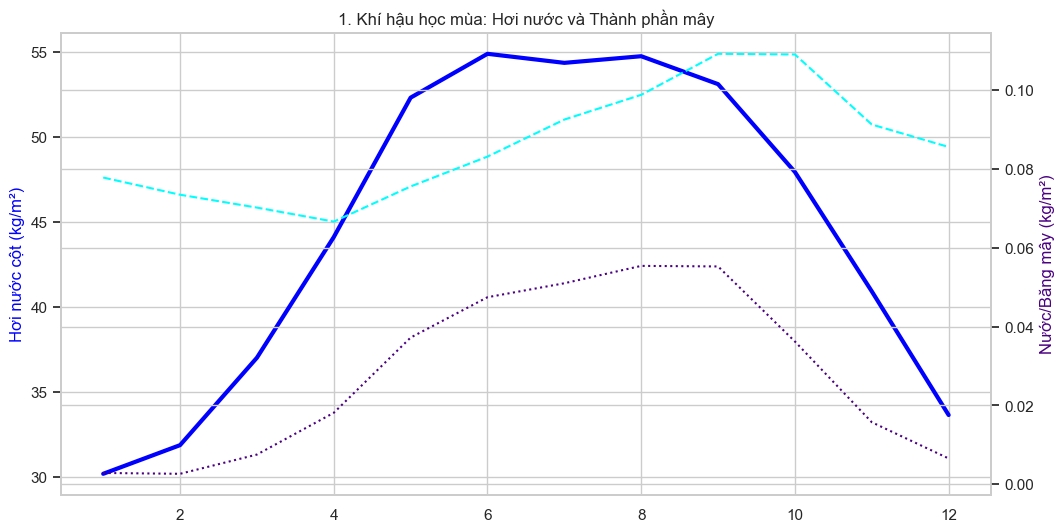

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(clim.index, clim['wvap'], color='blue', lw=3, label='TCWV')
ax1.set_ylabel('Hơi nước cột (kg/m²)', color='blue')
ax2 = ax1.twinx()
ax2.plot(clim.index, clim['clw'], color='cyan', ls='--', label='CLW')
ax2.plot(clim.index, clim['ciw'], color='indigo', ls=':', label='CIW')
ax2.set_ylabel('Nước/Băng mây (kg/m²)', color='indigo')
plt.title("1. Khí hậu học mùa: Hơi nước và Thành phần mây")
plt.show()

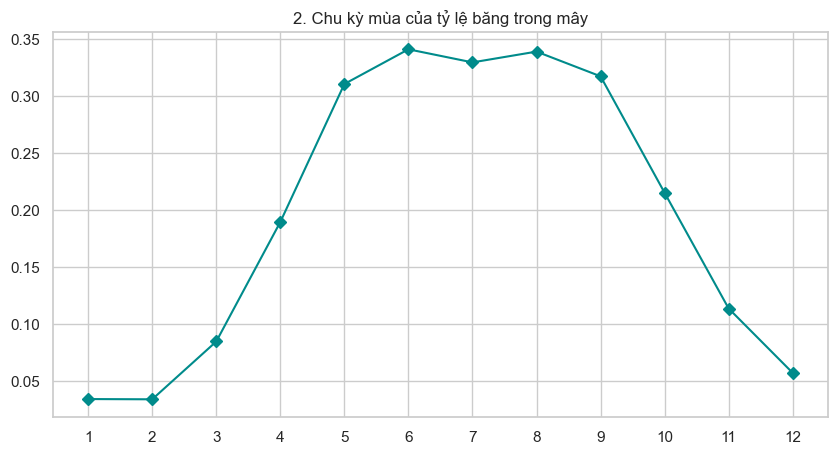

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(clim.index, clim['phase'], color='darkcyan', marker='D')
plt.title("2. Chu kỳ mùa của tỷ lệ băng trong mây")
plt.xticks(range(1, 13))
plt.show()

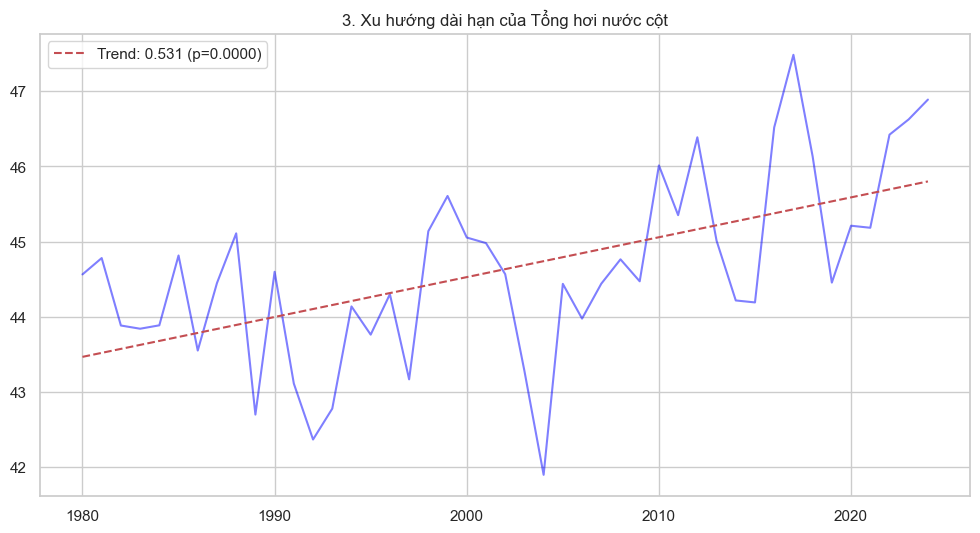

In [25]:
plt.figure(figsize=(12, 6))
x = df_yearly.index.year.values
y = df_yearly['wvap'].values
slope, intercept, _, p, _ = stats.linregress(x, y)
plt.plot(x, y, color='blue', alpha=0.5)
plt.plot(x, intercept + slope * x, 'r--', label=f'Trend: {slope*10:.3f} (p={p:.4f})')
plt.title("3. Xu hướng dài hạn của Tổng hơi nước cột")
plt.legend()
plt.show()

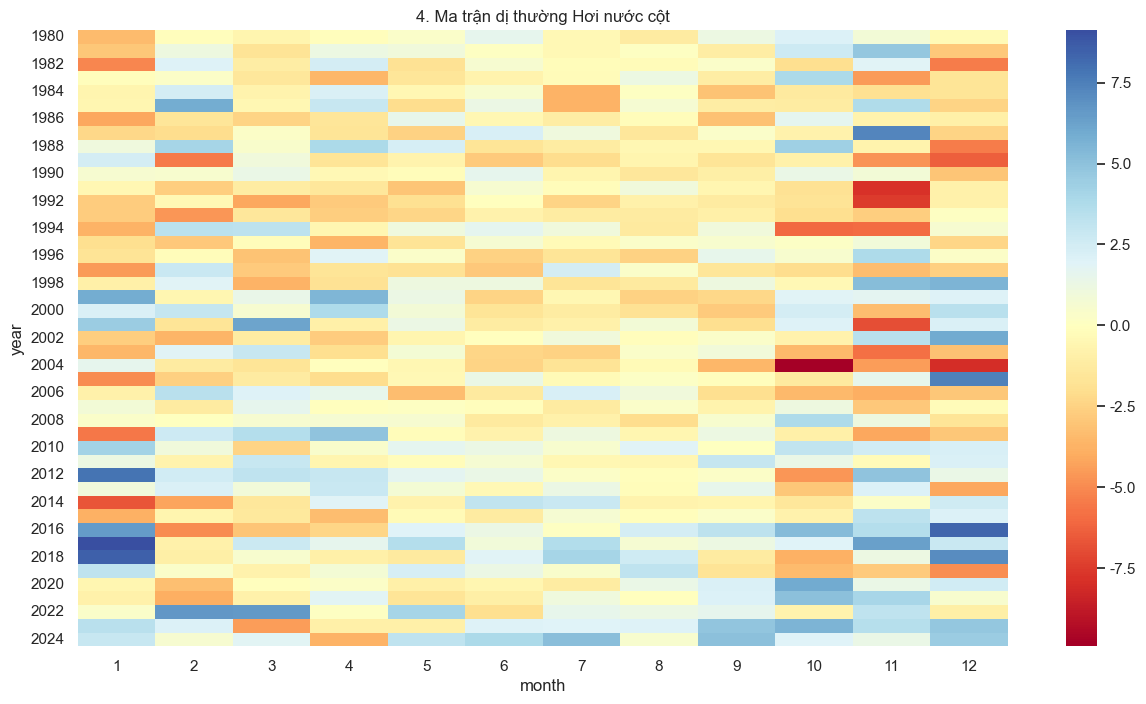

In [26]:
pivot = df_monthly.pivot(index='year', columns='month', values='wvap_anom')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap="RdYlBu", center=0)
plt.title("4. Ma trận dị thường Hơi nước cột")
plt.show()

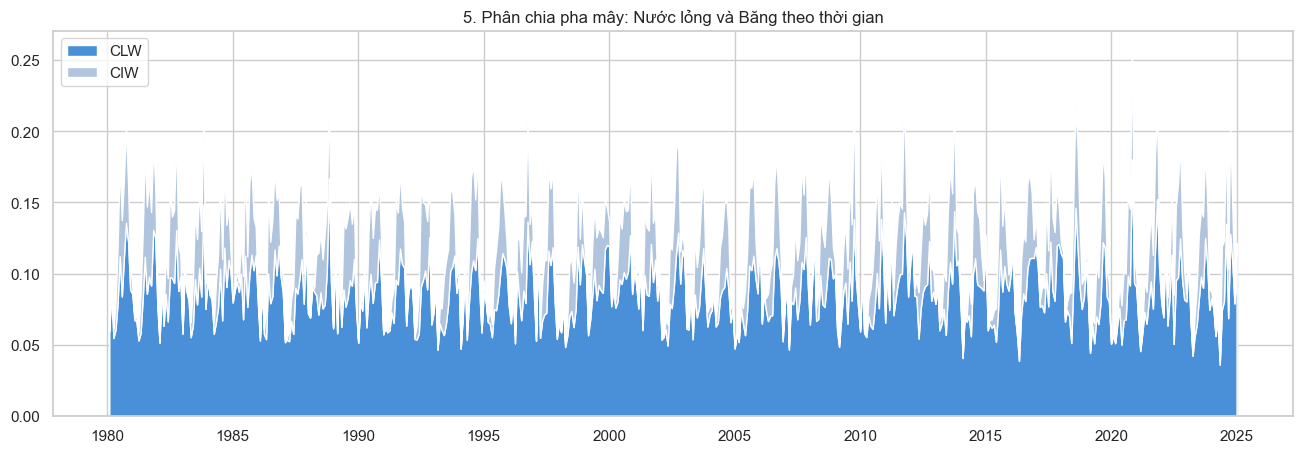

In [27]:
plt.figure(figsize=(16, 5))
plt.stackplot(df_monthly.index, df_monthly['clw'], df_monthly['ciw'], 
              labels=['CLW', 'CIW'], colors=['#4A90D9', '#B0C4DE'])
plt.title("5. Phân chia pha mây: Nước lỏng và Băng theo thời gian")
plt.legend(loc='upper left')
plt.show()

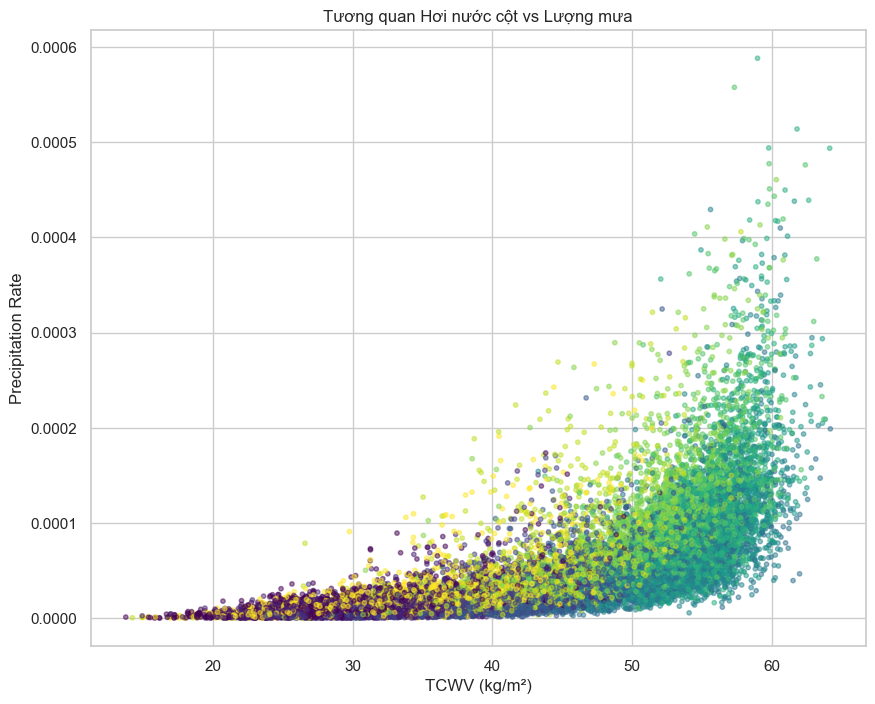

In [ ]:
try:
    tp_ds = xr.open_dataset(os.path.join(folder_path, 'mean_total_precipitation_rate_merged.nc'))

    if 'valid_time' in tp_ds.coords:
        tp_ds = tp_ds.rename({'valid_time': 'time'})

    if 'expver' in tp_ds.dims:
        tp_ds = tp_ds.mean(dim='expver')

    tp_ds = tp_ds.sortby('time')

    var_tp = list(tp_ds.data_vars)[0]

    tp_daily = tp_ds[var_tp] \
        .mean(dim=['latitude', 'longitude']) \
        .resample(time='1D').mean()

    plt.figure(figsize=(10, 8))
    plt.scatter(df_daily['wvap'], tp_daily.values,
                c=df_daily.index.month, cmap='viridis',
                s=10, alpha=0.5)

    plt.title("Tương quan Hơi nước cột vs Lượng mưa")
    plt.xlabel("TCWV (kg/m²)")
    plt.ylabel("Precipitation Rate")
    plt.show()

    tp_ds.close()

except Exception as e:
    print("Lỗi:", e)

In [29]:
try:
    cape_ds = xr.open_dataset(os.path.join(folder_path, 'convective_available_potential_energy_merged.nc'))
    if 'valid_time' in cape_ds.coords: cape_ds = cape_ds.rename({'valid_time': 'time'})
    if 'expver' in cape_ds.dims: cape_ds = cape_ds.mean(dim='expver')
    cape_daily = cape_ds[list(cape_ds.data_vars)[0]].mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
    
    plt.figure(figsize=(10, 8))
    plt.scatter(cape_daily.values, df_daily['ciw'], c=df_daily.index.month, cmap='magma', s=10, alpha=0.5)
    plt.title("7. Tương quan Băng mây (CIW) vs Chỉ số CAPE")
    plt.xlabel("CAPE (J/kg)")
    plt.ylabel("CIW (kg/m²)")
    plt.show()
    cape_ds.close()
except:
    print("File CAPE chưa sẵn sàng")

File CAPE chưa sẵn sàng
